In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

In [ ]:
import numpy as np

def anda(p, x):
    """
    Desloca cada elemento de x de acordo com p, com condição periódica.
    Se houver erro de índice, usa uma versão alternativa.
    """
    x = np.atleast_1d(x)
    p = np.atleast_1d(p)

    try:
        # Tenta executar a versão original que espera m > 1
        m, n = x.shape
        resultado = np.empty_like(x)
        for i in range(m):
            indices = (np.arange(n) - p[i].astype(int)) % n
            resultado[i] = x[i, indices]
        return resultado

    except Exception as e:
        # Se der erro (por exemplo, out of range), usa a versão simplificada
        n = len(x)
        indices = (np.arange(n) - p.astype(int)) % n
        return x[indices]

In [ ]:
class Dominio:
  def __init__(self,a=0,b=1,h=0.01,ti = 0,tf = 1,t = 0.01):
    self.a = a # ponto extremo esquerdo espaço
    self.b = b # ponto extremo direito espaço
    self.del_h = h # Passo no espaço
    self.ti = ti # tempo inicial
    self.tf = tf # tempo final
    self.del_t = t # Passo no tempo

In [ ]:
class cond_initial:
  '''Classe cond_initial define as funções das condições iniciais e para
  determiná-las só usamos
  a classe domínio'''
  def __init__(self,dom,ini = 1):
    self.ini = ini
    self.dom = dom

  def f_sin(self,x):
      '''Essa função tem como condição inicial a função seno
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      f = np.sin(2*np.pi*x/(self.dom.b - self.dom.a))
      return f

  def f_gauss(self,x):
      '''Essa função tem como condição inicial a função gaussiana com centro em
      0.5 e variância de 0.1
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      f = np.exp(-0.5*(x-0.5)**2/0.01)
      return f

  def f_quad(self,x):
      '''Essa função tem como condição inicial a função quadrada cuja largura é
      de 0.4
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      m = len(x)
      f = np.zeros(m)
      for i in range (m):
        if x[i] >= 0.3 and x[i] <= 0.700001:
          f[i] = 1
        else:
          f[i] = 0
      return f

  def f_triang(self,x):
      '''Essa função tem como condição inicial a função triangular
      As entradas dessa função são:
        x - pontos determinados entre a e b'''
      m = len(x)
      f = np.zeros(m)
      for i in range (m):
        if x[i] >= 0.3 and x[i] <= 0.15 +np.sqrt(2)/4:
          f[i] = x[i] - 0.3
        elif x[i] >= 0.15 +np.sqrt(2)/4 and x[i] <= np.sqrt(2)/2:
          f[i] = np.sqrt(2)/2 - x[i]
        else:
          f[i] = 0
      return f

In [ ]:
class interpol:
  '''Essa classe determina qual interpolação será feita entre os pontos
  determinados pelo donmínio'''
  def __init__(self,dom):
    self.dom = dom

  def P1(self,alp,p,x):
    """Função interpoladora de Lagrange linear, sendo que
    alp é o termo alpha que 0 < alpha < 1;
    x é o valor da função f nas posições."""
    x_ip   = anda(p,np.copy(x))
    #note que "q = p-1"
    x_iq = anda(1+p,np.copy(x))
    f = alp*x_iq + (1-alp)*x_ip
    return f

  def P2a(self,alp,p,x):
    """Função interpoladora de Lagrange quadrática, sendo que
    alp é o termo alpha que 0 < alpha < 1;
    x é o valor da função f nas posições."""
    #note que "ip = i-p"
    x_ip   = anda(p,np.copy(x))
    #note que "iq = i-p-1"
    x_iq = anda(1+p,np.copy(x))
    #note que "r = i-p-2"
    x_ir = anda(2+p,np.copy(x))
    f = (1-alp)*(2-alp)*0.5*x_ip + alp*(2-alp)*x_iq - alp*(1-alp)*0.5*x_ir
    return f

  def P2b(self,alp,p,x):
      """Função interpoladora de Lagrange quadrática, sendo que
      alp é o termo alpha que 0 < alpha < 1;
      x é o valor da função f nas posições."""
      #note que "ip = i-p"
      x_ip   = anda(0+p,np.copy(x))
      #note que "iq = i-p-1"
      x_iq = anda(1+p,np.copy(x))
      #note que "r = i-p+1"
      x_ir = anda(-1+p,np.copy(x))
      f = alp*(alp+1)*0.5*x_iq  -(alp-1)*(alp+1)*x_ip  + alp*(alp-1)*0.5*x_ir
      return f

  def P3(self,alp,p,x):
      """Função interpoladora de Lagrange cúbica, sendo que
      alp é o termo alpha que 0 < alpha < 1;
      x é o valor da função f nas posições."""
      #note que "is = i-p+1"
      x_is   = anda(-1+p,np.copy(x))
      #note que "ip = i-p"
      x_ip   = anda(p,np.copy(x))
      #note que "iq = i-p-1"
      x_iq = anda(1+p,np.copy(x))
      #note que "r = i-p-2"
      x_ir = anda(2+p,np.copy(x))
      f = ((1-alp)*(2-alp)*(1+alp)/2)*x_ip + ((alp)*(2-alp)*(1+alp)/2)*x_iq + ((alp)*(alp-1)*(1+alp)/6)*x_ir + ((-alp)*(2-alp)*(1-alp)/6)*x_is
      return f

In [ ]:
class perf_vel:
  '''Essa classe determina qual será o perfil de velocidade que será usado no
  problema, sendo esse perfil constante ou não'''
  def __init__(self,dom,cond,ini = 1):
    self.ini = ini
    self.dom = dom

  def const_1(self,x,t=0):
    '''Essa função define o perfil de velocidade constante, onde a velocidade de
    advecção é sqrt(2)
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c = np.sqrt(2)*np.ones(len(x))
    p = (c*self.dom.del_t/self.dom.del_h)//1
    alp = (c*self.dom.del_t/self.dom.del_h)%1
    return np.array([c,p,alp])

  def const_2(self,x,t=0):
    '''Essa função define o perfil de velocidade constante, onde a velocidade de
    advecção é sqrt(2)
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c = np.ones(len(x))
    p = (c*self.dom.del_t/self.dom.del_h)//1
    alp = (c*self.dom.del_t/self.dom.del_h)%1
    return np.array([c,p,alp])

  def n_const_1(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço, onde a
    velocidade de advecção é uma função do espaço
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = 10*np.sin(x*np.pi/(self.dom.b-self.dom.a))+1
    p = (c_x*self.dom.del_t/self.dom.del_h)//1
    alp = (c_x*self.dom.del_t/self.dom.del_h)%1
    return np.array([c_x,p,alp])

  def n_const_2(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço e no
    tempo, onde a velocidade de advecção é uma função do espaço e do tempo
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = 10*np.sin(x*np.pi/(self.dom.b-self.dom.a))*np.exp(-t/10)+1
    p = (c_x*self.dom.del_t/self.dom.del_h)//1
    alp = (c_x*self.dom.del_t/self.dom.del_h)%1
    return np.array([c_x,p,alp])

  def n_const_3(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço e no
    tempo, onde a velocidade de advecção é uma função do espaço e do tempo
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = 10*np.sin(x*np.pi/(self.dom.b-self.dom.a))*np.sin(2*(np.pi)*t/(self.dom.tf-self.dom.ti))
    p = (c_x*self.dom.del_t/self.dom.del_h)//1
    alp = (c_x*self.dom.del_t/self.dom.del_h)%1
    return np.array([c_x,p,alp])

  def n_const_4(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço e no
    tempo, onde a velocidade de advecção é uma função do espaço e do tempo
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = (10*np.sin(2*(np.pi)*t/(self.dom.tf-self.dom.ti)) + (1)**(1/2))*np.ones_like(x)
    p = (c_x*self.dom.del_t/self.dom.del_h)//1
    alp = (c_x*self.dom.del_t/self.dom.del_h)%1
    return np.array([c_x,p,alp])

  def n_const_5(self,x,t=0):
    '''Essa função define o perfil de velocidade não constante no espaço e no
    tempo, onde a velocidade de advecção é uma função do espaço e do tempo
    As variáveis desse perfil de advecção são
      x - posições dentro do domínio entre a e b
      t - tempo '''
    c_x = (10*np.sin(2*(np.pi)*t/(self.dom.tf-self.dom.ti)) + (2)**(1/2))*np.ones_like(x)
    p = (c_x*self.dom.del_t/self.dom.del_h)//1
    alp = (c_x*self.dom.del_t/self.dom.del_h)%1
    return np.array([c_x,p,alp])

In [ ]:
class find_departure:
  '''Essa classe determina qual será o perfil de velocidade que será usado no
  problema, sendo esse perfil constante ou não'''
  def __init__(self,dom,cond,ini = 1):
    self.ini = ini
    self.dom = dom

  def achar_departure_1(dom,inter,x,u_1,u_0, M = 5):
    """dom é o dominio de nosso problema.
      f é o perfil de velocidade de nosso problema.
      x são os pontos que serão usados em nosso problema.
      precisaremos de dois perfis de velocidade o primeiro será u_0 e o delta t a frente será u_1"""
    #os campos de velocidades no tempo -deltat e 0 serão iguais só por conveniência.
    u_para = np.copy(u_1)
    u_old = np.copy(u_0)
    u_new = np.copy(u_1)
    #agora temos que achar o valor da extrapolação de u no tempo +1/2
    u_extra = (3*u_new - u_old)*0.5 #esse termo é para podermos fazer a interpolação
    u_extra1 = np.copy(u_extra) # esses e o termo seguinte são para iterar e fazer o cálculo do erro


    for i in range(M):#aqui atualizo o ponto fixo
      m = (u_extra1*dom.del_t/(2*dom.del_h))//1
      gama = (u_extra1*dom.del_t/(2*dom.del_h))%1
      u_extra1 = inter(gama,m,u_extra)

    p = (u_extra1*dom.del_t/(dom.del_h))//1
    alp = (u_extra1*dom.del_t/(dom.del_h))%1

    return np.array([u_extra,p,alp])

  def SETTLS(dom,inter,x,u_1,u_0, M = 5):
    """dom é o dominio de nosso problema.
      f é o perfil de velocidade de nosso problema.
      x são os pontos que serão usados em nosso problema.
      precisaremos de dois perfis de velocidade o primeiro será u_0 e o delta t a frente será u_1"""
    #o paupite de depature point será o mesmo do arrival
    m = np.zeros_like(x)
    gama = np.zeros_like(x)
    #os campos de velocidades no tempo -deltat e 0 serão iguais só por conveniência.
    u_old = np.copy(u_0) #tempo t-deltat
    u_new = np.copy(u_1) #tempo t


    for i in range(M):#aqui atualizo o ponto fixo
      vd_old = inter(gama,m,u_old)
      vd_new = inter(gama,m,u_new)
      va_new = np.copy(u_new)

      settls = (2*vd_new - vd_old + va_new)*0.5

      m = (settls*dom.del_t/(dom.del_h))//1
      gama = (settls*dom.del_t/(dom.del_h))%1


    p = (settls*dom.del_t/(dom.del_h))//1
    alp = (settls*dom.del_t/(dom.del_h))%1
    return np.array([settls,p,alp])

In [ ]:
class linear_forcing:
  def __init__(self,dom,inter):
    self.dom = dom
    self.inter = inter

  def homogeneous(self,x,inter,f_old = 0, alpha = 0, p = 0,beta = 0):
    return np.zeros_like(x)

  def linear_beta(self,x,inter, f_old, alpha = 0, p = 0,beta = 0):
    r_departure = inter(alpha,p,f_old)
    f = beta*(r_departure + 0.5*dom.del_t*(alpha + p))
    return f

In [ ]:
class nonlinear_forcing:
  def __init__(self,dom,inter):
    self.dom = dom
    self.inter = inter

  def homogeneous(self,x,t,inter,f_old = 0, alpha = 0, p = 0,beta = 0):
    return np.zeros_like(x)

  def sine(self,x,t,inter,f_old, alpha = 0, p = 0,beta = 0):
    r_departure = inter(alpha,p,f_old)
    f = beta*np.sin(2*np.pi*r_departure + t)
    return f

#Para velocidade constante: c

In [ ]:
dom = Dominio(a=0,b=1,h=0.001,ti = 0,tf = 1,t = 0.001)
cond = cond_initial(dom)
inter = interpol(dom)
vel = perf_vel(dom,cond)
linear = linear_forcing(dom,inter)

In [ ]:
def adv_const(dom,inter_met,find_d,inter_ad,cond,vel_0,x_i,linear):
  '''Essa função faz com que a condição inicial seja advectada pelo perfil de
  velocidade constante se valendo de uma interpolação P
  As variáveis de nossa função são:
    dom - a classe de domíno
    inter - a classe de interpolação
    find_d - determina a função que faz a advecção
    cond - a classe de condição inicial
    vel - a classe de perfis de velocidade
    x_i - o espaço determinado pela condição inicial'''
  f_old = cond
  #Agora, determinar quem são os perfis de velocidade em 0 e em delta t
  u_old = vel_0
  u_new = vel_0

  for i in range(int((dom.tf-dom.ti)/dom.del_t)):
    u_p_alp = find_d(dom,inter_ad,x_i,u_new,u_old,M=5)
    f_new  = inter_met(u_p_alp[2],u_p_alp[1],f_old) + dom.del_t*linear(x = x_i,inter = inter_met,f_old = f_old,alpha = u_p_alp[2],p = u_p_alp[1],beta = -1)
    f_old = np.copy(f_new)
  return f_new

In [ ]:
x = np.arange(dom.a,dom.b,dom.del_h)
esp = np.array([x])

f_new        = adv_const(dom,inter_met = inter.P3,find_d = find_departure.SETTLS,inter_ad = inter.P1,cond = cond.f_sin(x),vel_0 = vel.const_1(x)[0],x_i=x,linear= linear.homogeneous)

In [ ]:
y = np.array([x,x])
y_cond_initial = np.array([cond.f_sin(x),cond.f_sin(x)])
y_vel_perf = np.array([vel.const_1(x)[0],(3**0.5)*vel.const_1(x)[0]])
y_alp = np.array([vel.const_1(x)[2],vel.const_1(x)[2]])
y_p = np.array([vel.const_1(x)[1],vel.const_1(x)[1]])

In [ ]:
print(y_cond_initial)
print(y_vel_perf)
print(y_alp)
print(y_p)

[[ 0.          0.00628314  0.01256604 ... -0.01884844 -0.01256604
  -0.00628314]
 [ 0.          0.00628314  0.01256604 ... -0.01884844 -0.01256604
  -0.00628314]]
[[1.41421356 1.41421356 1.41421356 ... 1.41421356 1.41421356 1.41421356]
 [2.44948974 2.44948974 2.44948974 ... 2.44948974 2.44948974 2.44948974]]
[[0.41421356 0.41421356 0.41421356 ... 0.41421356 0.41421356 0.41421356]
 [0.41421356 0.41421356 0.41421356 ... 0.41421356 0.41421356 0.41421356]]
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


In [ ]:
y_f_new        = adv_const(dom,inter_met = inter.P3,find_d = find_departure.SETTLS,inter_ad = inter.P1,cond = y_cond_initial,vel_0 = y_vel_perf,x_i=y,linear = linear.homogeneous)

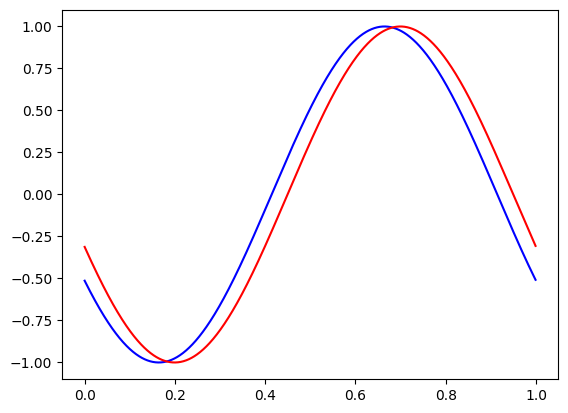

In [ ]:
plt.plot(x,y_f_new[0], color = 'b')
plt.plot(x,y_f_new[1], color =  'r')
plt.show()

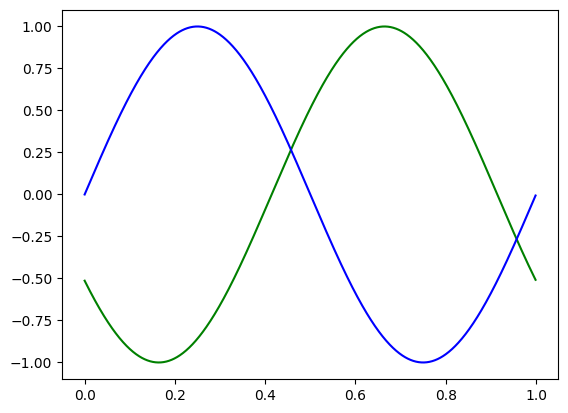

In [ ]:
plt.plot(x,f_new,color = 'g')
plt.plot(x,cond.f_sin(x), color = 'b')
plt.show()

#Para velocidade constante no tempo: c(x)

In [ ]:
dom = Dominio(a=0,b=1,h=0.001,ti = 0,tf = 1,t = 0.001)
cond = cond_initial(dom)
inter = interpol(dom)
vel = perf_vel(dom,cond)
linear = linear_forcing(dom,inter)

In [ ]:
def adv_const_t(dom,inter_met,find_d,inter_ad,cond,vel_0,x_i,linear):
  '''Essa função faz com que a condição inicial seja advectada pelo perfil de
  velocidade, variável no espaço, se valendo de uma interpolação P
  As variáveis de nossa função são:
    dom - a classe de domíno
    inter - a classe de interpolação
    cond - a classe de condição inicial
    vel - a classe de perfis de velocidade
    x_i - o espaço determinado pela condição inicial'''
  f_old = cond
  #Agora, determinar quem são os perfis de velocidade em 0 e em delta t
  u_old = vel_0
  u_new = vel_0

  for i in range(int((dom.tf-dom.ti)/dom.del_t)):
    u_p_alp = find_d(dom,inter_ad,x_i,u_new,u_old,M = 5)
    f_new  = inter_met(u_p_alp[2],u_p_alp[1],f_old) + dom.del_t*linear(x = x_i,inter = inter_met,f_old = f_old,alpha = u_p_alp[2],p = u_p_alp[1],beta = -1)
    f_old = np.copy(f_new)
  return f_new


In [ ]:
x = np.arange(dom.a,dom.b,dom.del_h)
f_new = adv_const_t(dom,inter_met = inter.P3, find_d= find_departure.SETTLS ,inter_ad = inter.P1,cond = cond.f_gauss(x),vel_0 = vel.n_const_4(x)[0],x_i=x, linear = linear.linear_beta)

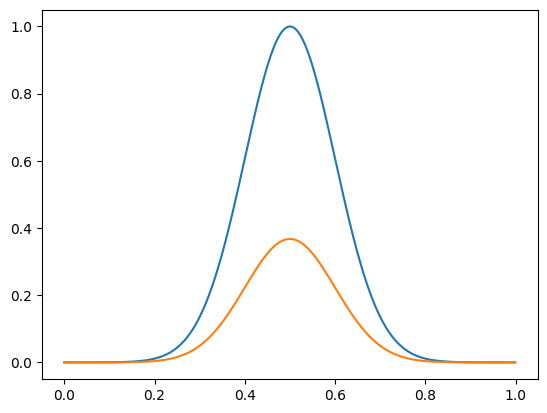

In [ ]:
plt.plot(x,cond.f_gauss(x))
plt.plot(x,f_new)
plt.show()

In [ ]:
y = np.array([x,x])
y_cond_initial = np.array([cond.f_gauss(x),cond.f_gauss(x)])
y_vel_perf = np.array([vel.n_const_1(x)[0],(3**0.5)*vel.n_const_1(x)[0]])
y_alp = np.array([vel.const_1(x)[2],vel.const_1(x)[2]])
y_p = np.array([vel.const_1(x)[1],vel.const_1(x)[1]])

In [ ]:
y_linear = np.array([linear.linear_beta,linear.homogeneous])

In [ ]:
y_f_new        = adv_const_t(dom,inter_met = inter.P3,find_d = find_departure.SETTLS,inter_ad = inter.P1,cond = y_cond_initial,vel_0 = y_vel_perf,x_i=y, linear=linear.linear_beta)

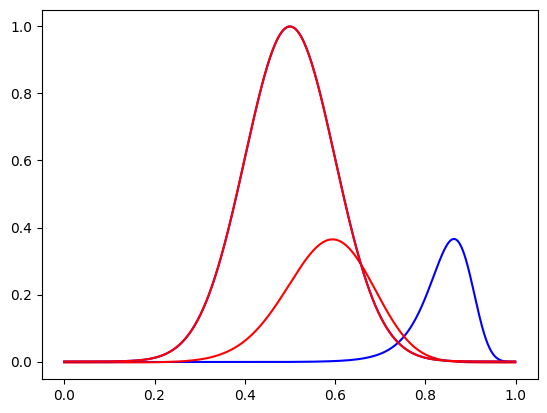

In [ ]:
plt.plot(x,y_f_new[0], color = 'b')
plt.plot(x,y_f_new[1], color =  'r')
plt.plot(x,y_cond_initial[0], color = 'b')
plt.plot(x,y_cond_initial[1], color =  'r')
plt.show()

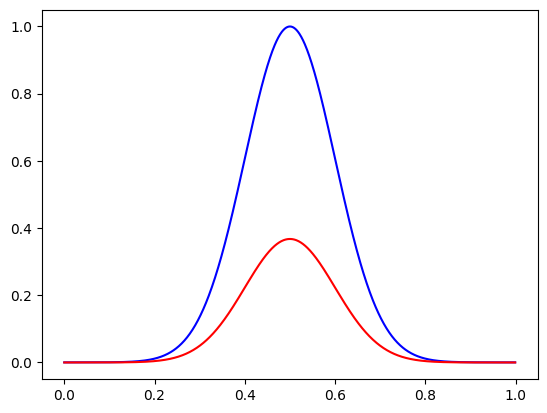

In [ ]:
plt.plot(x,cond.f_gauss(x),color = 'b')
plt.plot(x,f_new, color =  'r')
plt.show()

#Para velocidade não constante: c(x,t)

In [ ]:
dom = Dominio(a=0,b=1,h=0.0001,ti = 0,tf = 1,t = 0.001)
cond = cond_initial(dom)
inter = interpol(dom)
vel = perf_vel(dom,cond)
linear = linear_forcing(dom,inter)

In [ ]:
def adv_const_xt(dom,inter_met,find_d,inter_ad,cond,vel_0,x_i,linear):
  '''Essa função faz com que a condição inicial seja advectada pelo perfil de
  velocidade, variável no tempo e no espaço se valendo de uma interpolação P
  As variáveis de nossa função são:
    dom - a classe de domíno
    inter - a classe de interpolação
    cond - a classe de condição inicial
    vel - a classe de perfis de velocidade
    x_i - o espaço determinado pela condição inicial'''
  f_old = cond
  #Agora, determinar quem são os perfis de velocidade em 0 e em delta t

  u_old = vel_0(x_i,t = -dom.del_t + dom.ti)[0]
  u_new= vel_0(x_i,t = dom.ti)[0]

  for i in range(int((dom.tf-dom.ti)/dom.del_t)):
    u_p_alp = find_d(dom,inter_ad,x_i,u_new,u_old,M = 5)
    f_new  = inter_met(u_p_alp[2],u_p_alp[1],f_old) + + dom.del_t*linear(x = x_i,inter = inter_met,f_old = f_old,alpha = u_p_alp[2],p = u_p_alp[1],beta = -1)
    f_old = np.copy(f_new)
    u_old = np.copy(u_new)
    u_new = vel_0(x_i,t = dom.del_t*(i+1)+dom.ti)[0]
  return f_new

In [ ]:
x = np.arange(dom.a,dom.b,dom.del_h)
f_new = adv_const_xt(dom,inter_met = inter.P3, find_d= find_departure.SETTLS ,inter_ad = inter.P1,cond = cond.f_quad(x),vel_0 = vel.n_const_4,x_i=x, linear = linear.linear_beta)

In [ ]:
y = np.array([x,x])
y_cond_initial = np.array([cond.f_sin(x),cond.f_sin(x)])
y_vel_perf = np.array([vel.const_1(x)[0],(3**0.5)*vel.const_1(x)[0]])
y_alp = np.array([vel.const_1(x)[2],vel.const_1(x)[2]])
y_p = np.array([vel.const_1(x)[1],vel.const_1(x)[1]])

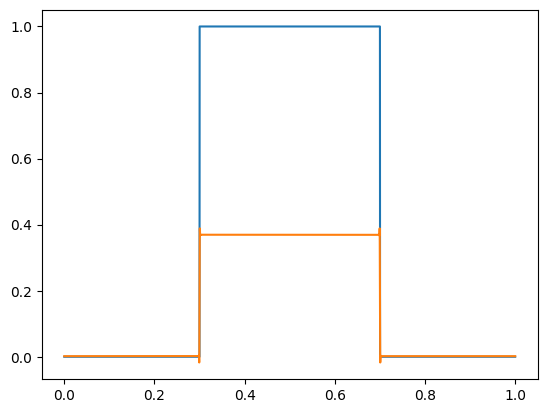

In [ ]:
plt.plot(x,cond.f_quad(x))
plt.plot(x,f_new)
plt.show()

#Burgers


In [ ]:
dom = Dominio(a=0,b=1,h=0.001,ti = 0,tf = 1,t = 0.001)
cond = cond_initial(dom)
inter = interpol(dom)
vel = perf_vel(dom,cond)
linear = linear_forcing(dom,inter)

In [ ]:
def Burgers(dom,inter_met,find_d,inter_ad,cond,vel_0,x_i,linear):
  '''Essa função faz com que a condição inicial seja advectada pelo perfil de
  velocidade, variável no tempo e no espaço se valendo de uma interpolação P
  As variáveis de nossa função são:
    dom - a classe de domíno
    inter - a classe de interpolação
    cond - a classe de condição inicial
    vel - a classe de perfis de velocidade
    x_i - o espaço determinado pela condição inicial'''
  f_old = cond
  #Agora, determinar quem são os perfis de velocidade em 0 e em delta t

  u_old = vel_0
  u_new= vel_0

  for i in range(int((dom.tf-dom.ti)/dom.del_t)):
    u_p_alp = find_d(dom,inter_ad,x_i,u_new,u_old,M = 5)

    f_new  = inter_met(u_p_alp[2],u_p_alp[1],f_old)
    f_old = np.copy(f_new)
    u_old = np.copy(u_new)
    u_new = np.copy(f_new)

  return f_new

In [ ]:
x = np.arange(dom.a,dom.b,dom.del_h)
f_new_b = Burgers(dom,inter_met = inter.P3, find_d= find_departure.SETTLS ,inter_ad = inter.P1,cond = cond.f_quad(x),vel_0 = cond.f_quad(x),x_i=x, linear = linear.homogeneous)

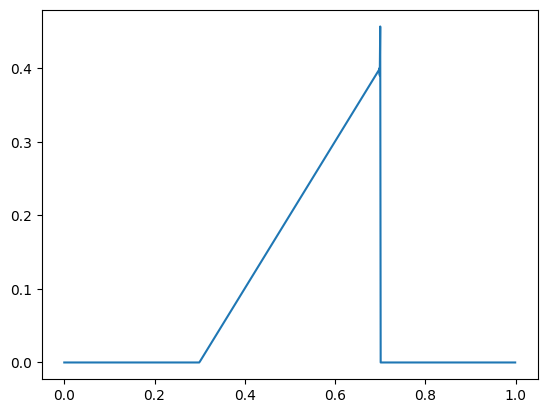

In [ ]:
#plt.plot(x,cond.f_quad(x))
plt.plot(x,f_new_b)
plt.show()

#Solução exata

In [ ]:
def f_adv(x):
    f = x
    return f

def const1(x,t):
  c = np.sqrt(2)*np.ones_like(x)
  return c

def const2(x,t):
  c = np.sqrt(1)*np.ones_like(x)
  return c


def c_n_const_1(x,t = 0):
    '''Essa função nos dá o perfil de velocidade variável no espaço'''
    c_x = 10*np.sin(x*np.pi/(dom.b-dom.a))+1
    return c_x

def c_n_const_2(x,t=0):
    '''Essa função nos dá o perfil de velocidade variável no espaço e no tempo'''
    c_x = 10*np.sin(x*np.pi/(dom.b-dom.a))*np.exp(-t/10)+1
    return c_x

def FTBS_conservativo(dom,f,x_i,c):
  '''Essa função se baseia em usar o método numérico de FTBS para a resolução
  da EDP proposta, e suas entradas são dadas por:
  'h' é o passo em y o qual é varido o problema
  'lamb' é a constante da divisão k/h
  'T' é o intervalo de tempo em que o programa irá rodar
  'x_i' é a condição inicial dada pelo problema
  'a' é a constante usada na equação diferencial que como padrão é posta como 1
  parece que está faltando a condição de contorno, mas ela será posta dentro da função.
  '''
  #########################
  h = dom.del_h
  lamb = dom.del_t/h
  T = dom.tf - dom.ti
  x_espaço = np.arange(dom.a,dom.b,dom.del_h)
  #########################

  x_old = x_i.copy()
  x_new = np.zeros(len(x_old))

  #iterações
  n_t = int(T/(h*lamb)-1)
  for i in range(1,n_t):
    x_new[1:] = x_old[1:] - c(x = x_espaço[1:],t = dom.del_t*i)*(f(x_old[1:])-f(x_old[:-1]))*lamb
    x_new[0] = x_new[-1]
    x_old = np.copy(x_new)

  return x_new


def Lax_Friedrichs_conservativo(dom,f,x_i,c):
  '''Essa função se baseia em usar o método numérico de Lax_Friedrichs-1 para a resolução
  da EDP proposta, e suas entradas são dadas por:
  'h' é o passo em y o qual é varido o problema
  'lamb' é a constante da divisão k/h
  'T' é o intervalo de tempo em que o programa irá rodar
  'x_i' é a condição inicial dada pelo problema
  'a' é a constante usada na equação diferencial que como padrão é posta como 1
  parece que está faltando a condição de contorno, mas ela será posta dentro da função.
  '''
  #########################
  h = dom.del_h
  lamb = dom.del_t/h
  T = dom.tf - dom.ti
  x_espaço = np.arange(dom.a,dom.b,dom.del_h)
  #########################

  x_old = x_i.copy()
  x_new = np.zeros_like(x_old)

  #iterações
  n_t = int(T/(h*lamb))
  for i in range(0,n_t - 1):
    x_new[1:-1] = (1/2)*(x_old[2:] + x_old[:-2]) - (c(x = x_espaço[1:-1],t =dom.del_t*i )*lamb/2)*(f(x_old[2:]) - f(x_old[:-2]))
    x_new[-1] =  (1/2)*(x_old[1] + x_old[-2]) - (c(x =x_espaço[-1],t =dom.del_t*i)*lamb/2)*(f(x_old[1]) - f(x_old[-2]))
    x_new[0] = x_new[-1]
    x_old = np.copy(x_new)

  return x_new

----------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------

#Análise de Erro
----------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------


In [ ]:
def reestrut(dom,n,x_i,x):
  k = len(x_i)
  indices = (n)*np.arange(k)
  x_new = x[indices]
  return x_new

def erro2(dom,er):
  erro2 = np.sqrt(np.sum(er**2)*dom.del_h)
  return erro2

def e2(h1,h2,e1,p):
  Er2 = e1*(h2/h1)**p
  return Er2

def graf_ordem(h1,h2,e1,n):
  e_2 = e2(h1,h2,e1,n)
  fig = plt.plot([h1,h2],[e1,e_2],color = 'k', linestyle = '--')

  plt.text(h2, e_2, r'$(\Delta t)^{%s}$' % n,
             fontsize=12, color='k',
             ha='left', va='bottom')
  return fig


def graf_dot_ordem1(h1,h2,e1):
  fig,ax = plt.subplots(figsize = (6,5))

  tab = np.zeros(4)
  tab[0] = e2(h1,h2,e1,0.5)
  tab[1] = e2(h1,h2,e1,1)
  tab[2] = e2(h1,h2,e1,2)
  tab[3] = e2(h1,h2,e1,3)

  o05 = ax.plot([h1,h2], [e1,tab[0]], color = 'k',label = '0.5º ordem',linestyle = ':')
  o1 = ax.plot([h1,h2], [e1,tab[1]], color = 'k',label = '1º ordem',linestyle = '-.')
  o2 = ax.plot([h1,h2], [e1,tab[2]], color = 'k',label = '3º ordem',linestyle = '--')
  o3 = ax.plot([h1,h2], [e1,tab[3]], color = 'k',label = '3º ordem',linestyle = '-' )
  return fig,ax,o05,o1,o2,o3


##Análise do erro para velocidade de constante interpolação linear

---



In [ ]:
dom_ex = Dominio(a=0,b=1,h=0.1*(2**-19),ti = 0,tf = 1,t = 0.1*(2**-14))
cond_ex = cond_initial(dom = dom_ex)
inter_ex = interpol(dom_ex)
vel_ex = perf_vel(dom_ex,cond_ex)

In [ ]:
#Definir a função exata, que no caso da advecção com velocidade é só a translação da onda

x_ex = np.arange(dom_ex.a,dom_ex.b,dom_ex.del_h)
v_ex = vel_ex.const_1
f_ex_0 = cond_ex.f_sin((x_ex - v_ex(x_ex)[0]*(dom_ex.tf-dom_ex.ti))%(dom_ex.b - dom_ex.a))
f_ex_1 = cond_ex.f_gauss((x_ex - v_ex(x_ex)[0]*(dom_ex.tf-dom_ex.ti))%(dom_ex.b - dom_ex.a))
f_ex_2 = cond_ex.f_quad((x_ex - v_ex(x_ex)[0]*(dom_ex.tf-dom_ex.ti))%(dom_ex.b - dom_ex.a))
f_ex_3 = cond_ex.f_triang((x_ex - v_ex(x_ex)[0]*(dom_ex.tf-dom_ex.ti))%(dom_ex.b - dom_ex.a))

KeyboardInterrupt: 

In [ ]:
#Definir quantas vezes vamos diminuir o delta h
m = 10

#definir os array de erro e delta h
er0 = np.zeros(m)
er1 = np.zeros(m)
er2 = np.zeros(m)
er3 = np.zeros(m)

DH = np.zeros(m)

for i in range(m):
  #definir o problema
  dom_it = Dominio(a=0, b=1, h=0.1*(2**(-i-2)), ti = 0, tf = 1, t = 0.01)
  cond_it = cond_initial(dom_it)
  inter_it = interpol(dom_it)
  vel_it = perf_vel(dom_it,cond_it)
  linear_it = linear_forcing(dom_it,inter_it)

  #definir o vetor x e a evolução do problema
  DH[i] = dom_it.del_h
  x_it = np.arange(dom_it.a,dom_it.b,dom_it.del_h)

  Inter_Met = inter_it.P1
  Find_d = find_departure.SETTLS
  Inter_Ad = inter_it.P1

  f_it_0 = adv_const(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_sin(x_it),     vel_0 = v_ex(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)
  f_it_1 = adv_const(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_gauss(x_it),   vel_0 = v_ex(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)
  f_it_2 = adv_const(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_quad(x_it),    vel_0 = v_ex(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)
  f_it_3 = adv_const(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_triang(x_it),  vel_0 = v_ex(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)

  #redimencionar a função exata para analisar erro
  n = int(dom_it.del_h/dom_ex.del_h)
  f_ex_i_0 = reestrut(dom_it,n,f_it_0,f_ex_0)
  f_ex_i_1 = reestrut(dom_it,n,f_it_1,f_ex_1)
  f_ex_i_2 = reestrut(dom_it,n,f_it_2,f_ex_2)
  f_ex_i_3 = reestrut(dom_it,n,f_it_3,f_ex_3)

  #coletar o valor do erro
  er0[i] = erro2(dom_it,f_ex_i_0 - f_it_0)
  er1[i] = erro2(dom_it,f_ex_i_1 - f_it_1)
  er2[i] = erro2(dom_it,f_ex_i_2 - f_it_2)
  er3[i] = erro2(dom_it,f_ex_i_3 - f_it_3)

  fig,ax1 = plt.subplots(figsize = (6,5))
  ax1.set_title('Error in terms of space - Δx = '+str(dom_it.del_h))
  ax1.set_xlabel('x')
  ax1.set_ylabel('Error',color = 'r')
  ax1.plot(x_it,np.abs(f_it_1 -f_ex_i_1), label = 'Gaussian error',color = 'r')
  ax1.legend()

  ax2 = ax1.twinx()
  ax2.plot(x_it,f_ex_i_1, label = 'Gaussian',color = 'b')
  ax2.set_ylabel('f(x)',color = 'b')
  ax2.legend()
  plt.show()

In [ ]:
print(DH)

In [ ]:
#linear interpolation

h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(2*10**(-2))


h1_ord3 = 10**(-4)
h2_ord3 = 3*h1_ord3
e_ord3 = np.min(10**(-6))

ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/2)
ord3 = graf_ordem(h1_ord3,h2_ord3,e_ord3,2)


#linear interpolation - \Dt proporcional a \Dx

'''h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(3*10**(-2))


h1_ord2 = 10**(-4)
h2_ord2 = 3*h1_ord2
e_ord2 = np.min(10**(-5))

h1_ord3 = 5*10**(-3)
h2_ord3 = 3*h1_ord3
e_ord3 = np.min(3*10**(-4))


ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/4)
ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,1)
ord3 = graf_ordem(h1_ord3,h2_ord3,e_ord3,3/4)'''

#cubic interpolation
'''
h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(10**(-2))

h1_ord2 = 10**(-3)
h2_ord2 = 3*h1_ord2
e_ord2 = np.min(3*10**(-5))

h1_ord3 = 6*10**(-3)
h2_ord3 = 3*h1_ord3
e_ord3 = np.min(10**(-7))

ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/2)
ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)
ord3 = graf_ordem(h1_ord3,h2_ord3,e_ord3,4)'''

#cubic interpolation - \Dt proporcional a \Dx
'''
h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(10**(-2))

h1_ord2 = 10**(-3)
h2_ord2 = 3*h1_ord2
e_ord2 = np.min(5*10**(-5))

h1_ord3 = 3*10**(-3)
h2_ord3 = 3*h1_ord3
e_ord3 = np.min(10**(-8))

ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/2)
ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,1)
ord3 = graf_ordem(h1_ord3,h2_ord3,e_ord3,3)'''



plt.plot(DH,er0,'o-',label = 'Sine',color = 'y')
plt.plot(DH,er1,'o-',label = 'Gauss',color = 'g')
plt.plot(DH,er2,'o-',label = 'Square', color = 'b')
plt.plot(DH,er3,'o-',label = 'Triangular', color = 'r')

plt.tick_params(axis='both', which='major', labelsize=12)

plt.title('Error x Δ t - Cubic interpolation ',fontsize = 16)
plt.xlabel('Δ t', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
#plt.ylim(10**-10,1)
plt.legend()
plt.loglog()
plt.show()

##Análise do erro para velocidade que varia com o espaço e no tempo


perfil de velocidade n_const4
---



In [ ]:
dom_ex2 = Dominio(a=0,b=1,h=0.1*(2**-19),ti = 0,tf = 1,t = 0.1*(2**-14))
cond_ex2 = cond_initial(dom = dom_ex2)
inter_ex2 = interpol(dom = dom_ex2)
vel_ex2 = perf_vel(dom = dom_ex2,cond = cond_ex2)

In [ ]:
#Definir a função exata, que no caso da advecção com velocidade é só a translação da onda

x_ex2 = np.arange(dom_ex2.a,dom_ex2.b,dom_ex2.del_h)
v_ex2 = vel_ex2.n_const_5

v_ex_2ef = 2**(1/2)

f_ex2_0 = cond_ex2.f_sin((x_ex2 - v_ex_2ef*dom_ex2.tf)%(dom_ex.b - dom_ex.a))
f_ex2_1 = cond_ex2.f_gauss((x_ex2- v_ex_2ef*dom_ex2.tf)%(dom_ex.b - dom_ex.a))
f_ex2_2 = cond_ex2.f_quad((x_ex2- v_ex_2ef*dom_ex2.tf)%(dom_ex.b - dom_ex.a))
f_ex2_3 = cond_ex2.f_triang((x_ex2- v_ex_2ef*dom_ex2.tf)%(dom_ex.b - dom_ex.a))

In [ ]:
#Definir quantas vezes vamos diminuir o delta h
m = 10

#definir os array de erro e delta h
er0_2 = np.zeros(m)
er1_2 = np.zeros(m)
er2_2 = np.zeros(m)
er3_2 = np.zeros(m)

DH_2 = np.zeros(m)

for i in range(m):
  #definir o problema
  dom_it = Dominio(a=0, b=1, h=0.1*(2**(-i-2)), ti = 0, tf = 1, t = 1*(2**(-i-2)))
  cond_it = cond_initial(dom = dom_it)
  inter_it = interpol(dom = dom_it)
  vel_it = perf_vel(dom = dom_it,cond = cond_it)
  linear_it = linear_forcing(dom = dom_it,inter = inter_it)

  #definir o vetor x e a evolução do problema
  DH_2[i] = dom_it.del_h
  x_it = np.arange(dom_it.a,dom_it.b,dom_it.del_h)

  Inter_Met = inter_it.P3
  Find_d = find_departure.SETTLS
  Inter_Ad = inter_it.P1

  f_it_0 = adv_const_t(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_sin(x_it),     vel_0 = v_ex2(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)
  f_it_1 = adv_const_t(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_gauss(x_it),   vel_0 = v_ex2(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)
  f_it_2 = adv_const_t(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_quad(x_it),    vel_0 = v_ex2(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)
  f_it_3 = adv_const_t(dom = dom_it,  inter_met = Inter_Met,   find_d = Find_d,  inter_ad = Inter_Ad,  cond = cond_it.f_triang(x_it),  vel_0 = v_ex2(x_it)[0],  x_i=x_it,linear= linear_it.homogeneous)

  #redimencionar a função exata para analisar erro
  n = int(dom_it.del_h/dom_ex2.del_h)
  f_ex2_i_0 = reestrut(dom_it,n,f_it_0,f_ex2_0)
  f_ex2_i_1 = reestrut(dom_it,n,f_it_1,f_ex2_1)
  f_ex2_i_2 = reestrut(dom_it,n,f_it_2,f_ex2_2)
  f_ex2_i_3 = reestrut(dom_it,n,f_it_3,f_ex2_3)

  #coletar o valor do erro
  er0_2[i] = erro2(dom_it,f_ex2_i_0 - f_it_0)
  er1_2[i] = erro2(dom_it,f_ex2_i_1 - f_it_1)
  er2_2[i] = erro2(dom_it,f_ex2_i_2 - f_it_2)
  er3_2[i] = erro2(dom_it,f_ex2_i_3 - f_it_3)


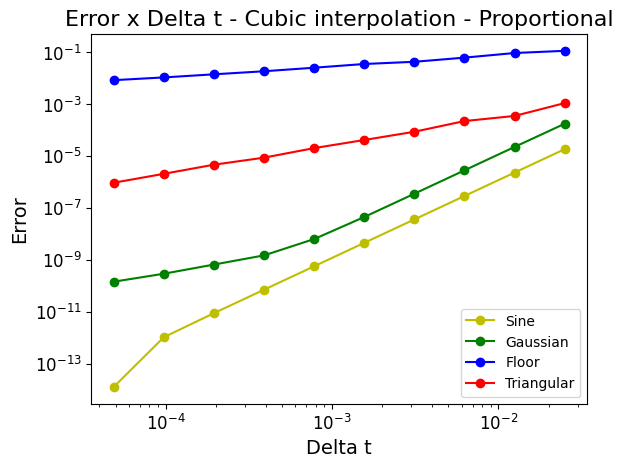

In [ ]:
# linear interpolation
'''
h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(5*10**(-3))

h1_ord2 = 7*10**(-4)
h2_ord2 = 3*h1_ord2
e_ord2 = np.min(4*10**(-5))


ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/2)
ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)'''


#linear interpolation - \Dt proporcional a \Dx
'''
h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(2*10**(-2))

h1_ord2 = 10**(-4)
h2_ord2 = 3*h1_ord2
e_ord2 = np.min(10**(-5))


ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/2)
ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,1)'''


# cubic interpolation
'''h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(10**(-3))

h1_ord2 = 7*10**(-4)
h2_ord2 = 3*h1_ord2
e_ord2 = np.min(4*10**(-5))

h1_ord3 = 2*10**(-3)
h2_ord3 = 3*h1_ord3
e_ord3 = np.min(10**(-8))


ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/2)
ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,2)
ord3 = graf_ordem(h1_ord3,h2_ord3,e_ord3,3)'''


#cubic interpolation - \Dt proporcional a \Dx
'''
h1_ord1 = 10**(-4)
h2_ord1 = 3*h1_ord1
e_ord1 = np.min(10**(-2))

h1_ord2 = 10**(-3)
h2_ord2 = 3*h1_ord2
e_ord2 = np.min(5*10**(-5))

h1_ord3 = 3*10**(-3)
h2_ord3 = 3*h1_ord3
e_ord3 = np.min(10**(-8))

ord1 = graf_ordem(h1_ord1,h2_ord1,e_ord1,1/2)
ord2 = graf_ordem(h1_ord2,h2_ord2,e_ord2,1)
ord3 = graf_ordem(h1_ord3,h2_ord3,e_ord3,3)'''


plt.plot(DH_2,er0_2,'o-',label = 'Sine',color = 'y')
plt.plot(DH_2,er1_2,'o-',label = 'Gaussian',color = 'g')
plt.plot(DH_2,er2_2,'o-',label = 'Floor', color = 'b')
plt.plot(DH_2,er3_2,'o-',label = 'Triangular', color = 'r')

plt.tick_params(axis='both', which='major', labelsize=12)

plt.title('Error x Delta t - Cubic interpolation - Proportional', fontsize = 16)
plt.xlabel('Delta t', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
plt.legend()
plt.loglog()
plt.show()

In [ ]:
#Definir quantas vezes vamos diminuir o delta h
m =7

#definir os array de erro e delta h
er_2_0 = np.zeros(m)
er_2_1 = np.zeros(m)
er_2_2 = np.zeros(m)
er_2_3 = np.zeros(m)

DH_2 = np.zeros(m)

for i in range(m):
  #definir o problema
  dom_it = Dominio(a=0, b=2, h=0.1*(2**(-i-6)), ti = 0, tf = 1, t  = 0.001 )
  #dom_it = Dominio(a=0, b=2, h=0.001, ti = 0, tf = 1, t = 0.01)
  cond_it = cond_initial(dom_it)
  inter_it = interpol(dom_it)
  vel_it = perf_vel(dom_it,cond_it)

  Inter_Met = inter_it.P1
  Inter_Ad = inter_it.P1

  #definir o vetor x e a evolução do problema
  DH_2[i] = dom_it.del_h
  x_it = np.arange(dom_it.a,dom_it.b,dom_it.del_h)
  f_it_2_0 = adv_const_xt(dom_it,  inter_met = Inter_Met,  inter_ad = Inter_Ad,  cond = cond_it.f_sin(x_it),    vel_0 = vel_it.n_const_4,  x_i=x_it)
  #f_it_2_1 = adv_const_xt(dom_it,  inter_met = Inter_Met,  inter_ad = Inter_Ad,  cond = cond_it.f_gauss(x_it),  vel_0 = vel_it.n_const_4,  x_i=x_it)
  #f_it_2_2 = adv_const_xt(dom_it,  inter_met = Inter_Met,  inter_ad = Inter_Ad,  cond = cond_it.f_quad(x_it),   vel_0 = vel_it.n_const_4,  x_i=x_it)
  #f_it_2_3 = adv_const_xt(dom_it,  inter_met = Inter_Met,  inter_ad = Inter_Ad,  cond = cond_it.f_triang(x_it), vel_0 = vel_it.n_const_4,  x_i=x_it)

  #plt.plot(x_it,f_it_2_2)
  #plt.show()
  #redimencionar a função exata para analisar erro
  n = int(dom_it.del_h/dom_ex2.del_h)

  f_ex_i_2_0 = reestrut(dom_it,n,f_it_2_0,f_ex2_0)
  #f_ex_i_2_1 = reestrut(dom_it,n,f_it_2_1,f_ex2_1)
  #f_ex_i_2_2 = reestrut(dom_it,n,f_it_2_2,f_ex2_2)
  #f_ex_i_2_3 = reestrut(dom_it,n,f_it_2_3,f_ex2_3)

  #coletar o valor do erro
  er_2_0[i] = erro2(dom_it,f_ex_i_2_0 - f_it_2_0)
  #er_2_1[i] = erro2(dom_it,f_ex_i_2_1 - f_it_2_1)
  #er_2_2[i] = erro2(dom_it,f_ex_i_2_2 - f_it_2_2)
  #er_2_3[i] = erro2(dom_it,f_ex_i_2_3 - f_it_2_3)

  fig,ax1 = plt.subplots(figsize = (6,5))
  ax1.set_title('Erro em função do espaço - com Delta h = '+str(dom_it.del_h))
  ax1.set_xlabel('x')
  ax1.set_ylabel('Erro',color = 'r')
  ax1.plot(x_it,np.abs(f_it_2_0 -f_ex_i_2_0), label = 'Erro da gaussiana',color = 'r')
  ax1.legend()

  ax2 = ax1.twinx()
  ax2.plot(x_it,f_ex_i_2_0, label = 'Gaussiana',color = 'b')
  #ax2.plot(x_it,f_it_2_0,label = 'teste',color = 'g')
  ax2.set_ylabel('f(x)',color = 'b')
  ax2.legend()
  plt.show()

In [ ]:
h1 = np.min(DH_2[:-1])
h2 = 2*h1
e1 = np.min(er_2_2[-1])


fig,ax,o05,o1,o2,o3 = graf_dot_ordem1(h1,h2,e1)
ax.scatter(DH_2,er_2_0,label = 'Seno',color = 'y')
ax.scatter(DH_2,er_2_1,label = 'Gauss',color = 'g')
ax.scatter(DH_2,er_2_2,label = 'Piso', color = 'b')
ax.scatter(DH_2,er_2_3,label = 'Triangular', color = 'r')

ax.set_title('Erro x Delta h - Interpolação P3')
ax.set_xlabel('Delta h')
ax.set_ylabel('erro')
ax.legend()
ax.loglog()
plt.show()
